In [2]:
import pandas as pd
import numpy as np

In [3]:

df = pd.read_json('script-bag-of-words.json')

In [4]:
df.head()

,episodeAlt,seasonNum,episodeNum,episodeTitle,text
0,S1E1,1,1,Winter Is Coming,"[{'text': 'Easy, boy.', 'name': 'Will'}, {'tex..."
1,S1E2,1,2,The Kingsroad,"[{'text': 'And You child... drink, eat. need t..."
2,S1E3,1,3,Lord Snow,[{'text': 'Council. Grand Lord Maester Pycelle...
3,S1E4,1,4,"Cripples, Bastards, and Broken Things",[{'text': 'Lord's The again. been dreaming lit...
4,S1E5,1,5,The Wolf and the Lion,[{'text': 'Does Hugh Ser any capital? family h...


In [5]:
df.tail()

,episodeAlt,seasonNum,episodeNum,episodeTitle,text
68,S8E2,8,2,A Knight of the Seven Kingdoms,"[{'name': 'Daenerys Targaryen', 'text': 'About..."
69,S8E3,8,3,The Long Night,"[{'name': 'Northman #1', 'text': 'Oi!'}, {'nam..."
70,S8E4,8,4,The Last of the Starks,"[{'name': 'Jon Snow', 'text': 'And Everyone It..."
71,S8E5,8,5,The Bells,"[{'name': 'Lord Varys', 'text': 'And? Come Not..."
72,S8E6,8,6,The Iron Throne,"[{'name': 'Tyrion Lannister', 'text': 'I'll fi..."


In [6]:
df.isna()

,episodeAlt,seasonNum,episodeNum,episodeTitle,text
0,False,False,False,False,False
1,False,False,False,False,False
2,False,False,False,False,False
3,False,False,False,False,False
4,False,False,False,False,False
...,...,...,...,...,...
68,False,False,False,False,False
69,False,False,False,False,False
70,False,False,False,False,False
71,False,False,False,False,False


In [7]:
df.isna().sum()

episodeAlt      0
seasonNum       0
episodeNum      0
episodeTitle    0
text            0
dtype: int64

In [8]:
df.describe()

,seasonNum,episodeNum
count,73.000000,73.000000
mean,4.205479,5.191781
std,2.191897,2.821827
min,1.000000,1.000000
25%,2.000000,3.000000
50%,4.000000,5.000000
75%,6.000000,7.000000
max,8.000000,10.000000


In [9]:
df.iloc[-1]['text']

[{'name': 'Tyrion Lannister', 'text': "I'll find later. you"},
 {'name': 'Jon Snow', 'text': "It's Let me men not safe. send some with you."},
 {'name': 'Tyrion Lannister', 'text': "I'm alone. going"},
 {'name': 'Grey Worm',
  'text': 'Daenerys I In Queen, Targaryen, die. name of one sentence the the to true you'},
 {'name': 'Jon Snow',
  'text': "Grey It's These Worm! are men over. prisoners."},
 {'name': 'Grey Worm',
  'text': "It Queen's are defeated. enemies is not over the until"},
 {'name': 'Davos Seaworth',
  'text': "How They're be? defeated do knees. more much on their them to want you"},
 {'name': 'Grey Worm', 'text': 'They are breathing.'},
 {'name': 'Davos Seaworth', 'text': 'Look We around friend. won. you,'},
 {'name': 'Grey Worm', 'text': "I commands, my not obey queen's yours."},
 {'name': 'Jon Snow', 'text': "And Queen's are commands? the what"},
 {'name': 'Grey Worm',
  'text': '"Kill Cersei Lannister." These They all are chose fight follow for free her. men. to who'}

In [10]:
dialogue = {}
for index, row in df.iterrows():
    for item in row['text']:
        if item['name'] in dialogue:
            dialogue[item['name']] = dialogue[item['name']] + item['text']
        else:
            dialogue[item['name']] = item['text'] + " "
            

In [11]:
len(dialogue)

817

In [12]:
new_df  = pd.DataFrame()

In [13]:
new_df['character'] = dialogue.keys()
new_df['words'] = dialogue.values()

In [14]:
new_df.iloc[:,0:3].head()

,character,words
0,Will,"Easy, boy. I've I've Wildlings a a do ever in ..."
1,Waymar Royce,One They're What a and another before d'you ea...
2,Gared,Wall. We back head should the to Our They We W...
3,Jon Snow,Father's Go on. watching. And mother. yourBran...
4,Septa Mordane,"Fine Well always. as done. work, I Quite beaut..."


In [16]:
new_df['num_words'] = new_df['words'].apply( lambda x:len(x.split()))

In [17]:
new_df = new_df.sort_values('num_words',ascending = False)

In [18]:
new_df = new_df.head(100)

In [19]:
new_df.shape

(100, 3)

In [20]:
new_df.head()

,character,words,num_words
17,Tyrion Lannister,It Mmh. Northern about girls. is say the they ...,25924
13,Cersei Lannister,And And Casterly One Rock. When about afraid. ...,14294
3,Jon Snow,Father's Go on. watching. And mother. yourBran...,11488
20,Daenerys Targaryen,We've a and anything. asked been for for guest...,11202
12,Jaime Lannister,"As I It's brother, duty feel it's much. my sho...",10823


In [21]:
from sklearn.feature_extraction.text import CountVectorizer
cv = CountVectorizer(stop_words = 'english')


In [22]:
embeddings = cv.fit_transform(new_df['words']).toarray()

In [23]:
embeddings = embeddings.astype('float64')

In [24]:
from sklearn.manifold import TSNE

In [25]:
tsne = TSNE(n_components=2, verbose=1, random_state=123)
z = tsne.fit_transform(embeddings)

[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 100 samples in 0.001s...
[t-SNE] Computed neighbors for 100 samples in 3.246s...
[t-SNE] Computed conditional probabilities for sample 100 / 100
[t-SNE] Mean sigma: 14.377887
[t-SNE] KL divergence after 250 iterations with early exaggeration: 61.158485
[t-SNE] KL divergence after 1000 iterations: 0.293064


In [26]:
z.shape

(100, 2)

In [27]:
new_df['x'] = z.T[0]

In [28]:
new_df['y'] = z.T[1]

In [29]:
new_df

,character,words,num_words,x,y
17,Tyrion Lannister,It Mmh. Northern about girls. is say the they ...,25924,2.347044,4.562169
13,Cersei Lannister,And And Casterly One Rock. When about afraid. ...,14294,2.323790,4.309062
3,Jon Snow,Father's Go on. watching. And mother. yourBran...,11488,2.575524,4.184408
20,Daenerys Targaryen,We've a and anything. asked been for for guest...,11202,1.912773,3.811602
12,Jaime Lannister,"As I It's brother, duty feel it's much. my sho...",10823,2.416410,4.124201
...,...,...,...,...,...
132,Rickard Karstark,Castle I'll King North! Red The They and can c...,466,2.577115,-2.516322
57,Syrio Forel,"Tomorrow You are at be boy. here late, midday....",462,4.149331,-2.313863
112,Kevan Lannister,Tyrion. Catelyn Golden Jaime Lords River River...,460,3.608604,-2.244392
365,Mace Tyrell,"From Grace, House Margaery May Reach, Tyrell Y...",450,3.754857,-2.127214


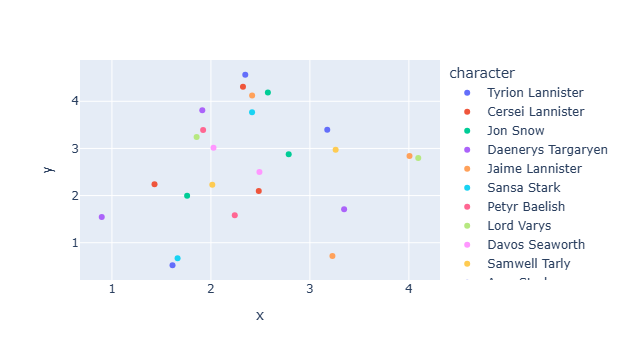

In [30]:
import plotly.express as px 
fig = px.scatter(new_df.head(25), x="x" , y="y" , color = "character")
fig.show()

In [31]:
import json
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import pickle

# Load characters data
with open('characters.json', 'r') as f:
    data = json.load(f)

# Convert to dataframe
df = pd.DataFrame(data)
print(df.columns.tolist())
print(df.head(2))
print(f"Total characters: {len(df)}")

['characters']
                                          characters
0  {'characterName': 'Addam Marbrand', 'character...
1  {'characterName': 'Aegon Targaryen', 'houseNam...
Total characters: 389


In [32]:
# Extract nested character data
df_chars = pd.json_normalize(df['characters'])
print(df_chars.columns.tolist())
print(df_chars.head(2))

['characterName', 'characterLink', 'actorName', 'actorLink', 'houseName', 'royal', 'parents', 'siblings', 'killedBy', 'characterImageThumb', 'characterImageFull', 'nickname', 'killed', 'servedBy', 'parentOf', 'marriedEngaged', 'serves', 'kingsguard', 'guardedBy', 'actors', 'guardianOf', 'allies', 'abductedBy', 'abducted', 'sibling']
     characterName          characterLink  actorName         actorLink  \
0   Addam Marbrand  /character/ch0305333/  B.J. Hogg  /name/nm0389698/   
1  Aegon Targaryen                    NaN        NaN               NaN   

   houseName royal                            parents  \
0        NaN   NaN                                NaN   
1  Targaryen  True  [Elia Martell, Rhaegar Targaryen]   

                        siblings          killedBy characterImageThumb  ...  \
0                            NaN               NaN                 NaN  ...   
1  [Rhaenys Targaryen, Jon Snow]  [Gregor Clegane]                 NaN  ...   

  marriedEngaged serves kingsgua

In [33]:
import json
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import pickle

# ── Load + Extract ────────────────────────────────────
with open('characters.json', 'r') as f:
    data = json.load(f)

df = pd.json_normalize(pd.DataFrame(data)['characters'])

# ── Feature Engineering ───────────────────────────────
def safe_join(val):
    if isinstance(val, list):
        return ' '.join([str(v) for v in val if v])
    return str(val) if pd.notna(val) else ''

df['tags'] = (
    df['houseName'].apply(safe_join) + ' ' +
    df['allies'].apply(safe_join) + ' ' +
    df['serves'].apply(safe_join) + ' ' +
    df['servedBy'].apply(safe_join) + ' ' +
    df['parents'].apply(safe_join) + ' ' +
    df['siblings'].apply(safe_join) + ' ' +
    df['killedBy'].apply(safe_join) + ' ' +
    df['killed'].apply(safe_join) + ' ' +
    df['guardedBy'].apply(safe_join) + ' ' +
    df['kingsguard'].apply(safe_join) + ' ' +
    df['royal'].apply(safe_join)
)

df['tags'] = df['tags'].str.lower().str.strip()

# ── Keep only useful columns ──────────────────────────
df_final = df[[
    'characterName', 'actorName', 'houseName',
    'royal', 'characterImageThumb', 'characterImageFull',
    'nickname', 'allies', 'tags'
]].copy()

df_final['characterName'] = df_final['characterName'].fillna('Unknown')
df_final = df_final[df_final['characterName'] != 'Unknown']
df_final = df_final.reset_index(drop=True)

print(f"Total characters: {len(df_final)}")
print(df_final[['characterName', 'houseName', 'tags']].head(3))

# ── TF-IDF + Similarity ───────────────────────────────
tfidf = TfidfVectorizer(max_features=500, stop_words='english')
matrix = tfidf.fit_transform(df_final['tags'])
similarity = cosine_similarity(matrix).astype(np.float32)

print(f"\nSimilarity matrix: {similarity.shape}")

# ── Save Pickle Files ─────────────────────────────────
pickle.dump(df_final, open('characters.pkl', 'wb'))
pickle.dump(similarity, open('similarity.pkl', 'wb'))

import os
print(f"\ncharacters.pkl: {os.path.getsize('characters.pkl')/1024:.1f} KB")
print(f"similarity.pkl: {os.path.getsize('similarity.pkl')/1024:.1f} KB")
print("\n✅ Done! Ready to build app.py")

Total characters: 389
     characterName  houseName  \
0   Addam Marbrand        NaN   
1  Aegon Targaryen  Targaryen   
2    Aeron Greyjoy    Greyjoy   

                                                tags  
0                                                     
1  targaryen    elia martell rhaegar targaryen rh...  
2            greyjoy     balon greyjoy euron greyjoy  

Similarity matrix: (389, 389)

characters.pkl: 109.5 KB
similarity.pkl: 591.3 KB

✅ Done! Ready to build app.py
